Parámetros de adquisición
  equipment           : Nikon XT H 225
  energy_kV           : 150
  pixel_size_um       : 20
  material            : Mortero de cemento
  phases              : ['Poros', 'Resina', 'Matriz de cemento']


Información de la imagen
  Dimensiones        : 1180 x 1188 píxeles
  Campo de visión    : 23.60 x 23.76 mm
  Tipo de dato       : uint16
  Valor mínimo       : 4930
  Valor máximo       : 59483
  Media              : 24073.0
  Desviación estándar: 10078.8


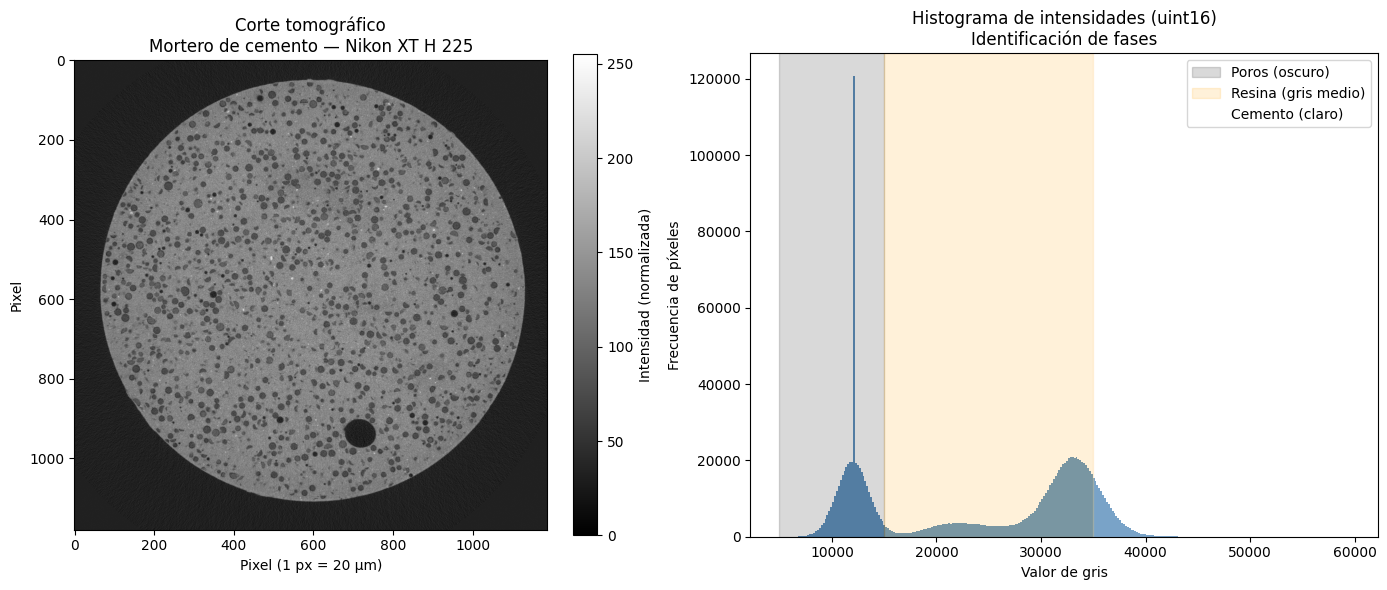


  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\01_exploracion_imagen.png


In [1]:
# ============================================================
# PROYECTO 01 - Análisis de Porosidad en Mortero de Cemento
# 1. Exploración y comprensión de los datos
# ============================================================
# Autor: Peter Zabala Medina, PhD
# Equipo: Nikon XT H 225
# ============================================================

import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ------------------------------------------------------------
# 1.1 - Parámetros de adquisición
# ------------------------------------------------------------
# Estos parámetros convierten los resultados de píxeles a 
# unidades físicas reales. Son la base de todo el análisis.

ACQUISITION_PARAMS = {
    "equipment"  : "Nikon XT H 225",
    "energy_kV"  : 150,
    "pixel_size_um": 20,        # micrones por pixel
    "material"   : "Mortero de cemento",
    "phases"     : ["Poros", "Resina", "Matriz de cemento"],
}

print("=" * 50)
print("Parámetros de adquisición")
print("=" * 50)
for key, value in ACQUISITION_PARAMS.items():
    print(f"  {key:20s}: {value}")

# ------------------------------------------------------------
# 1.2 - Rutas del proyecto
# ------------------------------------------------------------

BASE_DIR    = Path(r"C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis")
DATA_RAW    = BASE_DIR / "data" / "raw"
FIGURES_DIR = BASE_DIR / "figures"
RESULTS_DIR = BASE_DIR / "results"

IMAGE_PATH  = DATA_RAW / "Mortero5bin20821.tif"

# ------------------------------------------------------------
# 1.3 - Carga de imagen
# Nota: esta función es el punto de entrada del pipeline.
# En el proyecto 3D, se llamará una vez por corte dentro
# de un loop de procesamiento por lotes.
# ------------------------------------------------------------

def load_image(path: Path) -> np.ndarray:
    """
    Carga una imagen TIFF de cortes tomográficos.
    
    Parameters
    ----------
    path : Path
        Ruta al archivo .tif
    
    Returns
    -------
    np.ndarray
        Imagen en formato uint16
    """
    img = tifffile.imread(path)
    return img

img = load_image(IMAGE_PATH)

# ------------------------------------------------------------
# 1.4 - Información básica de la imagen
# ------------------------------------------------------------

pixel_size  = ACQUISITION_PARAMS["pixel_size_um"]
height, width = img.shape
fov_mm = (height * pixel_size / 1000, width * pixel_size / 1000)

print("\n")
print("=" * 50)
print("Información de la imagen")
print("=" * 50)
print(f"  Dimensiones        : {height} x {width} píxeles")
print(f"  Campo de visión    : {fov_mm[0]:.2f} x {fov_mm[1]:.2f} mm")
print(f"  Tipo de dato       : {img.dtype}")
print(f"  Valor mínimo       : {img.min()}")
print(f"  Valor máximo       : {img.max()}")
print(f"  Media              : {img.mean():.1f}")
print(f"  Desviación estándar: {img.std():.1f}")

# ------------------------------------------------------------
# 1.5 - Visualización exploratoria
# ------------------------------------------------------------

def plot_exploration(img: np.ndarray, params: dict, save_path: Path) -> None:
    """
    Genera figura exploratoria con imagen e histograma de intensidades.
    Identifica visualmente las fases presentes en la muestra.

    Parameters
    ----------
    img     : np.ndarray  Imagen tomográfica uint16
    params  : dict        Parámetros de adquisición
    save_path : Path      Ruta donde guardar la figura
    """
    # Normalizar a uint8 solo para visualización
    img_vis = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)

    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

    # --- Imagen ---
    ax0 = fig.add_subplot(gs[0])
    im  = ax0.imshow(img_vis, cmap="gray")
    ax0.set_title(f"Corte tomográfico\n{params['material']} — {params['equipment']}", fontsize=12)
    ax0.set_xlabel(f"Pixel (1 px = {params['pixel_size_um']} µm)")
    ax0.set_ylabel("Pixel")
    plt.colorbar(im, ax=ax0, fraction=0.046, label="Intensidad (normalizada)")

    # --- Histograma ---
    ax1 = fig.add_subplot(gs[1])
    ax1.hist(img.ravel(), bins=300, color="steelblue", alpha=0.85, linewidth=0.3)
    ax1.set_title("Histograma de intensidades (uint16)\nIdentificación de fases", fontsize=12)
    ax1.set_xlabel("Valor de gris")
    ax1.set_ylabel("Frecuencia de píxeles")

    # Anotaciones de fases (aproximadas — se ajustan en 3)
    ax1.axvspan(img.min(), 15000, alpha=0.15, color="black",  label="Poros (oscuro)")
    ax1.axvspan(15000,     35000, alpha=0.15, color="orange", label="Resina (gris medio)")
    ax1.axvspan(35000, img.max(), alpha=0.15, color="white",  label="Cemento (claro)")
    ax1.legend(fontsize=10)

    plt.tight_layout()
    out = save_path / "01_exploracion_imagen.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Figura guardada en: {out}")

plot_exploration(img, ACQUISITION_PARAMS, FIGURES_DIR)

Normalización
  Tipo original    : uint16  rango [4930, 59483]
  Tipo normalizado : float32  rango [0.000, 1.000]

  SNR estimado     : 1.90
  Evaluación       : Ruido significativo — filtrado recomendado


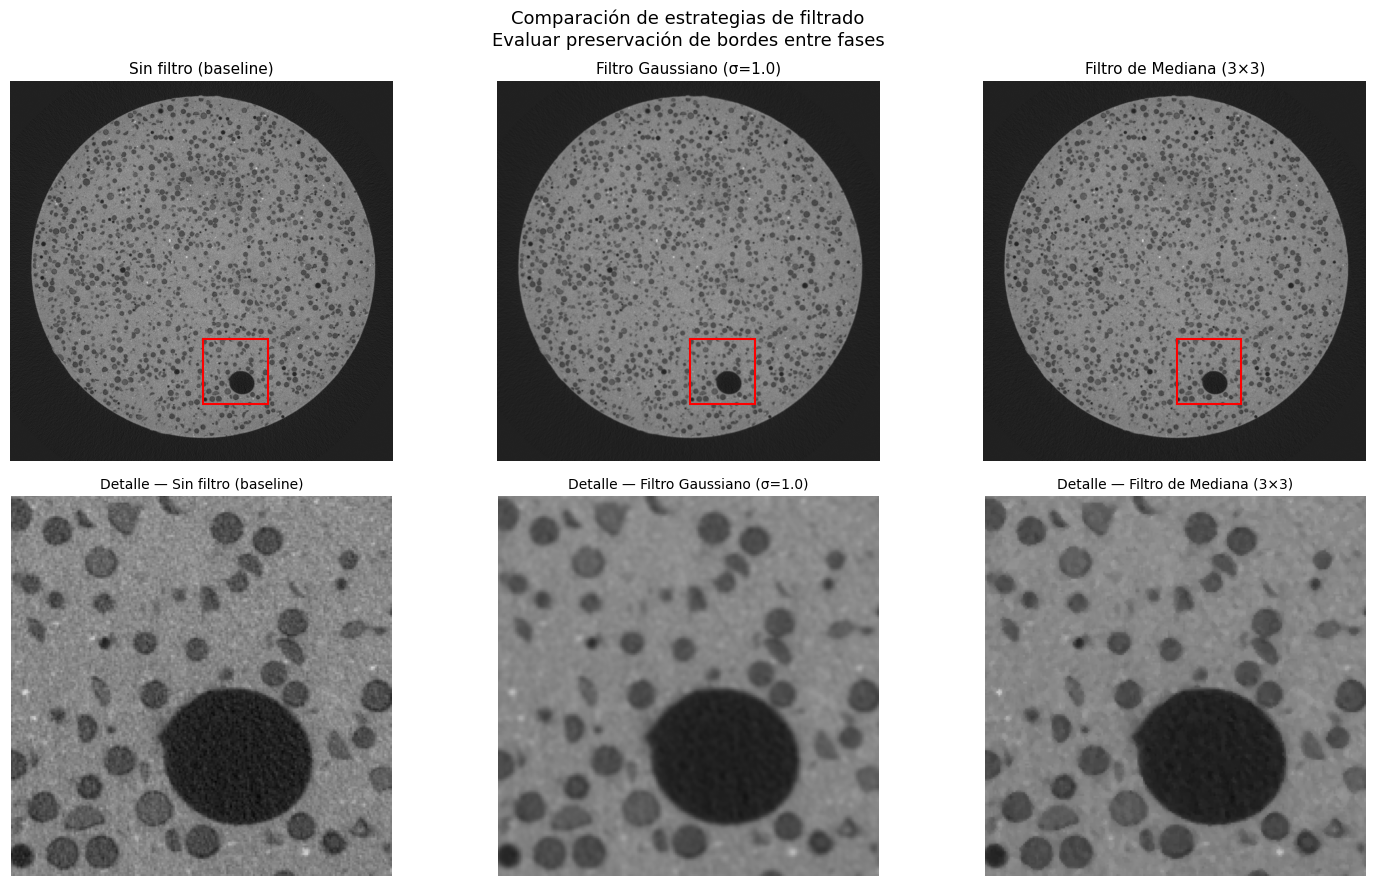

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\02_comparacion_filtros.png


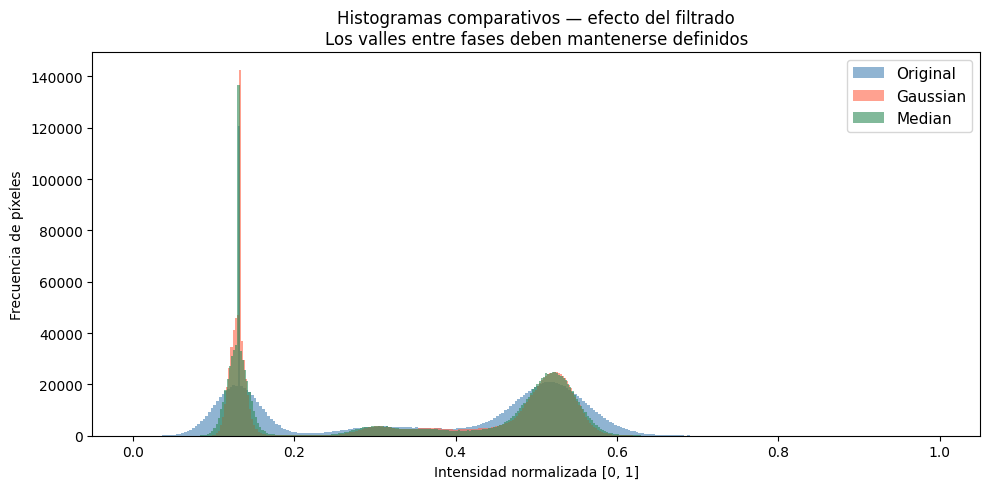

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\02_histogramas_filtrado.png


Imagen preprocesada lista para segmentación
  Filtro seleccionado : median
  Shape               : (1180, 1188)
  Dtype               : float32
  Rango               : [0.065, 0.876]


In [13]:
# ============================================================
# 2. - Preprocesamiento
# ============================================================
# Objetivo: preparar la imagen para la segmentación.
# Decisiones tomadas acá afectan directamente la calidad
# de las máscaras en 3.
# ============================================================

from scipy.ndimage import gaussian_filter, median_filter
from skimage.exposure import rescale_intensity

# ------------------------------------------------------------
# 2.1 - Normalización de intensidades
# Convertimos uint16 a float32 en rango [0, 1].
# Trabajar en float evita errores de overflow en operaciones
# posteriores y es la práctica estándar en CV científica.
# ------------------------------------------------------------

def normalize_image(img: np.ndarray) -> np.ndarray:
    """
    Normaliza una imagen uint16 a float32 en rango [0, 1].
    
    Parameters
    ----------
    img : np.ndarray
        Imagen original uint16
    
    Returns
    -------
    np.ndarray
        Imagen normalizada float32 en [0, 1]
    """
    img_float = img.astype(np.float32)
    img_norm  = (img_float - img_float.min()) / (img_float.max() - img_float.min())
    return img_norm

img_norm = normalize_image(img)

print("=" * 50)
print("Normalización")
print("=" * 50)
print(f"  Tipo original    : {img.dtype}  rango [{img.min()}, {img.max()}]")
print(f"  Tipo normalizado : {img_norm.dtype}  rango [{img_norm.min():.3f}, {img_norm.max():.3f}]")

# ------------------------------------------------------------
# 2.2 - Evaluación de ruido
# Antes de filtrar, evaluamos si la imagen lo necesita.
# En imágenes de microCT de buena calidad muchas veces
# el filtrado no mejora — y puede borrar bordes reales.
# Calculamos el SNR como métrica objetiva.
# ------------------------------------------------------------

def estimate_snr(img: np.ndarray) -> float:
    """
    Estima el Signal-to-Noise Ratio como mean/std.
    Un SNR > 10 generalmente indica imagen de buena calidad.

    Parameters
    ----------
    img : np.ndarray
        Imagen normalizada float32

    Returns
    -------
    float
        Valor de SNR estimado
    """
    snr = img.mean() / img.std()
    return snr

snr = estimate_snr(img_norm)
print(f"\n  SNR estimado     : {snr:.2f}")
print(f"  Evaluación       : {'Buena calidad — filtrado opcional' if snr > 5 else 'Ruido significativo — filtrado recomendado'}")

# ------------------------------------------------------------
# 2.3 - Comparación de filtros
# Evaluamos tres opciones:
#   - Sin filtro (baseline)
#   - Filtro gaussiano (suavizado general)
#   - Filtro de mediana (preserva bordes mejor)
# La decisión final se toma visualmente y con el histograma.
# ------------------------------------------------------------

def apply_filters(img: np.ndarray, gaussian_sigma: float = 1.0,
                  median_size: int = 3) -> dict:
    """
    Aplica filtros de suavizado y retorna todas las versiones
    para comparación visual.

    Parameters
    ----------
    img            : np.ndarray  Imagen normalizada float32
    gaussian_sigma : float       Sigma para filtro gaussiano
    median_size    : int         Tamaño de ventana para mediana

    Returns
    -------
    dict con versiones: original, gaussian, median
    """
    return {
        "original" : img,
        "gaussian" : gaussian_filter(img, sigma=gaussian_sigma).astype(np.float32),
        "median"   : median_filter(img,  size=median_size).astype(np.float32),
    }

filtered_versions = apply_filters(img_norm, gaussian_sigma=1.0, median_size=3)

# ------------------------------------------------------------
# 2.4 - Visualización comparativa de filtros
# ------------------------------------------------------------

def plot_filter_comparison(versions: dict, save_path: Path) -> None:
    """
    Figura comparativa de las tres versiones de filtrado.
    Incluye imagen y detalle ampliado para evaluar bordes,
    más histograma superpuesto para comparar distribuciones.

    Parameters
    ----------
    versions  : dict   Diccionario con versiones filtradas
    save_path : Path   Ruta donde guardar la figura
    """
    titles = {
        "original" : "Sin filtro (baseline)",
        "gaussian" : "Filtro Gaussiano (σ=1.0)",
        "median"   : "Filtro de Mediana (3×3)",
    }

    # Región de detalle para comparar bordes
    row_s, row_e = 800, 1000
    col_s, col_e = 600, 800

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for col, (key, img_v) in enumerate(versions.items()):

        # Fila superior — imagen completa
        axes[0, col].imshow(img_v, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(titles[key], fontsize=11)
        axes[0, col].add_patch(plt.Rectangle(
            (col_s, row_s), col_e - col_s, row_e - row_s,
            edgecolor="red", facecolor="none", linewidth=1.5))
        axes[0, col].axis("off")

        # Fila inferior — detalle ampliado
        axes[1, col].imshow(img_v[row_s:row_e, col_s:col_e],
                            cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title(f"Detalle — {titles[key]}", fontsize=10)
        axes[1, col].axis("off")

    plt.suptitle("Comparación de estrategias de filtrado\n"
                 "Evaluar preservación de bordes entre fases", fontsize=13)
    plt.tight_layout()
    out = save_path / "02_comparacion_filtros.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")


def plot_histogram_comparison(versions: dict, save_path: Path) -> None:
    """
    Histogramas superpuestos de las tres versiones.
    Permite evaluar si el filtrado borra separación entre fases.

    Parameters
    ----------
    versions  : dict   Diccionario con versiones filtradas
    save_path : Path   Ruta donde guardar la figura
    """
    colors = {"original": "steelblue", "gaussian": "tomato", "median": "seagreen"}

    fig, ax = plt.subplots(figsize=(10, 5))
    for key, img_v in versions.items():
        ax.hist(img_v.ravel(), bins=300, alpha=0.6,
                color=colors[key], label=key.capitalize(), linewidth=0.3)

    ax.set_title("Histogramas comparativos — efecto del filtrado\n"
                 "Los valles entre fases deben mantenerse definidos", fontsize=12)
    ax.set_xlabel("Intensidad normalizada [0, 1]")
    ax.set_ylabel("Frecuencia de píxeles")
    ax.legend(fontsize=11)

    plt.tight_layout()
    out = save_path / "02_histogramas_filtrado.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")


plot_filter_comparison(filtered_versions, FIGURES_DIR)
plot_histogram_comparison(filtered_versions, FIGURES_DIR)

# ------------------------------------------------------------
# 2.5 - Selección de imagen preprocesada
# Después de evaluar las figuras anteriores, elegís cuál
# versión usar en el Acto 3. Por defecto usamos mediana
# porque preserva mejor los bordes entre fases.
# Cambiá la key si tu evaluación visual indica otra cosa.
# ------------------------------------------------------------

FILTER_SELECTED = "median"   # opciones: "original", "gaussian", "median"

img_preprocessed = filtered_versions[FILTER_SELECTED]

print("\n")
print("=" * 50)
print("Imagen preprocesada lista para segmentación")
print("=" * 50)
print(f"  Filtro seleccionado : {FILTER_SELECTED}")
print(f"  Shape               : {img_preprocessed.shape}")
print(f"  Dtype               : {img_preprocessed.dtype}")
print(f"  Rango               : [{img_preprocessed.min():.3f}, {img_preprocessed.max():.3f}]")